In [133]:
import sys

print("Hello, Cancer Informatics!")
print(sys.executable)
print(sys.version)


Hello, Cancer Informatics!
/opt/anaconda3/envs/cancer-informatics/bin/python
3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]


In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import sklearn

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)

print("Environment ready for TCGA-BRCA analysis!")

pandas: 2.3.3
numpy: 2.5.1
scipy: 1.18.0
scikit-learn: 1.9.0
Environment ready for TCGA-BRCA analysis!


In [135]:
import pandas as pd
print(pd.__version__)

2.3.3


In [136]:
import numpy as np
print(np.__version__)


2.5.1


In [137]:
import scipy
print(scipy.__version__)

1.18.0


In [138]:
import sklearn
print(sklearn.__version__)

1.9.0


In [139]:
import matplotlib.pyplot as plt
print("matplotlib OK")

matplotlib OK


In [140]:
import requests

In [141]:
import requests

In [142]:
url = "https://api.gdc.cancer.gov/cases"

response = requests.get(url)

print(response.status_code)

200


In [143]:
import json

filters = {
    "op": "in",
    "content": {
        "field": "project.project_id",
        "value": ["TCGA-BRCA"]
    }
}

params = {
    "filters": json.dumps(filters),
    "size": 5
}

response = requests.get(
    "https://api.gdc.cancer.gov/cases",
    params=params
)

print(response.status_code)

200


In [144]:
data = response.json()
data

{'data': {'hits': [{'id': '57a1604c-60b7-4b30-a75e-f70939532c5c',
    'slide_ids': ['643fd386-3bcb-4ee1-a030-1e34eeefeb04',
     'b3643e0d-dc70-4fd2-a0e0-534890f73da1'],
    'submitter_slide_ids': ['TCGA-BH-A0B2-01A-01-TSA',
     'TCGA-BH-A0B2-01A-01-BSA'],
    'disease_type': 'Ductal and Lobular Neoplasms',
    'analyte_ids': ['97f3d921-4fe1-40ad-9f84-e0537372ad3f',
     'c7efa2f3-6724-4cc6-a375-4c6026c019e9',
     'e4b5ef86-2bda-4498-a4f0-42d1a0a65a05',
     '41054d29-473d-4db6-9523-feb4000486a2',
     'fe787c20-f983-4e10-a08b-72a48d07e303'],
    'submitter_id': 'TCGA-BH-A0B2',
    'submitter_analyte_ids': ['TCGA-BH-A0B2-01A-11R',
     'TCGA-BH-A0B2-01A-11D',
     'TCGA-BH-A0B2-10A-01D',
     'TCGA-BH-A0B2-01A-11W',
     'TCGA-BH-A0B2-10A-01W'],
    'aliquot_ids': ['30143b3f-7a18-446f-b3b9-18a6748d7155',
     '760f4cd1-ad18-4acd-a1c9-a9c3f396658d',
     '0a8c0095-44df-4b5e-9479-4a9920692a06',
     'a27c5907-1ad2-4414-a9c9-448f1b484946',
     'de5fed7f-9770-4cb3-85bd-1b0bec7440da',
  

In [145]:
hits = data["data"]["hits"]

print("Number of cases returned:", len(hits))

Number of cases returned: 5


In [146]:
hits[0]

{'id': '57a1604c-60b7-4b30-a75e-f70939532c5c',
 'slide_ids': ['643fd386-3bcb-4ee1-a030-1e34eeefeb04',
  'b3643e0d-dc70-4fd2-a0e0-534890f73da1'],
 'submitter_slide_ids': ['TCGA-BH-A0B2-01A-01-TSA', 'TCGA-BH-A0B2-01A-01-BSA'],
 'disease_type': 'Ductal and Lobular Neoplasms',
 'analyte_ids': ['97f3d921-4fe1-40ad-9f84-e0537372ad3f',
  'c7efa2f3-6724-4cc6-a375-4c6026c019e9',
  'e4b5ef86-2bda-4498-a4f0-42d1a0a65a05',
  '41054d29-473d-4db6-9523-feb4000486a2',
  'fe787c20-f983-4e10-a08b-72a48d07e303'],
 'submitter_id': 'TCGA-BH-A0B2',
 'submitter_analyte_ids': ['TCGA-BH-A0B2-01A-11R',
  'TCGA-BH-A0B2-01A-11D',
  'TCGA-BH-A0B2-10A-01D',
  'TCGA-BH-A0B2-01A-11W',
  'TCGA-BH-A0B2-10A-01W'],
 'aliquot_ids': ['30143b3f-7a18-446f-b3b9-18a6748d7155',
  '760f4cd1-ad18-4acd-a1c9-a9c3f396658d',
  '0a8c0095-44df-4b5e-9479-4a9920692a06',
  'a27c5907-1ad2-4414-a9c9-448f1b484946',
  'de5fed7f-9770-4cb3-85bd-1b0bec7440da',
  '3a713c13-5bc4-4d9c-9e6f-85b2aaa8d85e',
  'ae2856f4-dafc-45b6-96af-6c6615cf9475',
  

In [147]:
print("Case ID:", hits[0]["id"])
print("Submitter ID:", hits[0]["submitter_id"])
print("Disease type:", hits[0]["disease_type"])

Case ID: 57a1604c-60b7-4b30-a75e-f70939532c5c
Submitter ID: TCGA-BH-A0B2
Disease type: Ductal and Lobular Neoplasms


In [148]:
for case in hits:
    print(case["submitter_id"])

TCGA-BH-A0B2
TCGA-A8-A08S
TCGA-A8-A09C
TCGA-BH-A1F5
TCGA-A2-A0YT


In [149]:
case_data = []

for case in hits:
    case_data.append({
        "case_id": case["id"],
        "submitter_id": case["submitter_id"],
        "disease_type": case["disease_type"]
    })

df_cases = pd.DataFrame(case_data)

df_cases

,case_id,submitter_id,disease_type
0,57a1604c-60b7-4b30-a75e-f70939532c5c,TCGA-BH-A0B2,Ductal and Lobular Neoplasms
1,2779fa01-ac93-4e80-a997-3385f72172c3,TCGA-A8-A08S,Ductal and Lobular Neoplasms
2,80f3f48a-cc21-415c-b181-c77e7ba1c563,TCGA-A8-A09C,Ductal and Lobular Neoplasms
3,e663954c-05a8-479a-a623-400c1eb5efc6,TCGA-BH-A1F5,Ductal and Lobular Neoplasms
4,14b95463-2108-4921-afc2-e29eef52b18f,TCGA-A2-A0YT,Ductal and Lobular Neoplasms


In [150]:
clinical_fields = [
    "case_id",
    "submitter_id",
    "demographic.gender",
    "demographic.vital_status",
    "demographic.age_at_index",
    "diagnoses.age_at_diagnosis",
    "diagnoses.ajcc_pathologic_stage",
    "diagnoses.days_to_death",
    "diagnoses.days_to_last_follow_up"
]

In [151]:
params = {
    "filters": json.dumps(filters),
    "fields": ",".join(clinical_fields),
    "format": "JSON",
    "size": 5
}

response = requests.get(
    "https://api.gdc.cancer.gov/cases",
    params=params
)

print(response.status_code)

200


In [152]:
clinical_data = response.json()
clinical_hits = clinical_data["data"]["hits"]

clinical_hits[0]

{'id': '57a1604c-60b7-4b30-a75e-f70939532c5c',
 'case_id': '57a1604c-60b7-4b30-a75e-f70939532c5c',
 'submitter_id': 'TCGA-BH-A0B2'}

In [153]:
clinical_rows = []

for case in clinical_hits:
    demographic = case.get("demographic", {})
    diagnoses = case.get("diagnoses", [])

    diagnosis = diagnoses[0] if diagnoses else {}

    clinical_rows.append({
        "patient_id": case.get("submitter_id"),
        "gender": demographic.get("gender"),
        "vital_status": demographic.get("vital_status"),
        "age_at_index": demographic.get("age_at_index"),
        "age_at_diagnosis_days": diagnosis.get("age_at_diagnosis"),
        "pathologic_stage": diagnosis.get("ajcc_pathologic_stage"),
        "days_to_death": diagnosis.get("days_to_death"),
        "days_to_last_follow_up": diagnosis.get("days_to_last_follow_up")
    })

clinical_df = pd.DataFrame(clinical_rows)

clinical_df

,patient_id,gender,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,None,None,NaN,NaN,None,None,None
1,TCGA-A8-A08S,None,Alive,71.0,NaN,None,None,None
2,TCGA-A8-A09C,None,Alive,69.0,25355.0,Stage X,None,None
3,TCGA-BH-A1F5,None,Dead,62.0,22842.0,Stage IIA,None,None
4,TCGA-A2-A0YT,None,Dead,56.0,20482.0,Stage IIIB,None,None


In [154]:
params = {
    "filters": json.dumps(filters),
    "fields": ",".join(clinical_fields),
    "format": "JSON",
    "size": 2000
}

response = requests.get(
    "https://api.gdc.cancer.gov/cases",
    params=params
)

print(response.status_code)

200


In [155]:
clinical_data = response.json()
clinical_hits = clinical_data["data"]["hits"]

print("Number of TCGA-BRCA cases returned:", len(clinical_hits))

Number of TCGA-BRCA cases returned: 1098


In [156]:
clinical_rows = []

for case in clinical_hits:
    demographic = case.get("demographic", {})
    diagnoses = case.get("diagnoses", [])

    diagnosis = diagnoses[0] if diagnoses else {}

    clinical_rows.append({
        "patient_id": case.get("submitter_id"),
        "gender": demographic.get("gender"),
        "vital_status": demographic.get("vital_status"),
        "age_at_index": demographic.get("age_at_index"),
        "age_at_diagnosis_days": diagnosis.get("age_at_diagnosis"),
        "pathologic_stage": diagnosis.get("ajcc_pathologic_stage"),
        "days_to_death": diagnosis.get("days_to_death"),
        "days_to_last_follow_up": diagnosis.get("days_to_last_follow_up")
    })

clinical_df = pd.DataFrame(clinical_rows)

clinical_df.shape

(1098, 8)

In [157]:
clinical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1098 entries, 0 to 1097
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   patient_id              1098 non-null   object 
 1   gender                  0 non-null      object 
 2   vital_status            1097 non-null   object 
 3   age_at_index            1097 non-null   float64
 4   age_at_diagnosis_days   1050 non-null   float64
 5   pathologic_stage        996 non-null    object 
 6   days_to_death           0 non-null      object 
 7   days_to_last_follow_up  1 non-null      float64
dtypes: float64(3), object(5)
memory usage: 68.8+ KB


In [158]:
missing_summary = pd.DataFrame({
    "missing_count": clinical_df.isna().sum(),
    "missing_percent": clinical_df.isna().mean() * 100
})

missing_summary

,missing_count,missing_percent
patient_id,0,0.000000
gender,1098,100.000000
vital_status,1,0.091075
age_at_index,1,0.091075
age_at_diagnosis_days,48,4.371585
pathologic_stage,102,9.289617
days_to_death,1098,100.000000
days_to_last_follow_up,1097,99.908925


In [159]:
clinical_hits[0].get("demographic", {})

{}

In [160]:
clinical_hits[0].get("diagnoses", [])

[]

In [161]:
clinical_fields_v2 = [
    "case_id",
    "submitter_id",
    "demographic.gender",
    "demographic.vital_status",
    "demographic.age_at_index",
    "diagnoses.age_at_diagnosis",
    "diagnoses.ajcc_pathologic_stage",
    "diagnoses.days_to_death",
    "diagnoses.days_to_last_follow_up"
]

params_v2 = {
    "filters": json.dumps(filters),
    "fields": ",".join(clinical_fields_v2),
    "expand": "demographic,diagnoses",
    "format": "JSON",
    "size": 2000
}

response_v2 = requests.get(
    "https://api.gdc.cancer.gov/cases",
    params=params_v2
)

print(response_v2.status_code)

200


In [162]:
clinical_data_v2 = response_v2.json()
clinical_hits_v2 = clinical_data_v2["data"]["hits"]

print("Cases:", len(clinical_hits_v2))
print("\nDemographic:")
print(clinical_hits_v2[0].get("demographic", {}))

print("\nDiagnosis:")
print(clinical_hits_v2[0].get("diagnoses", []))

Cases: 1098

Demographic:
{}

Diagnosis:
[]


In [163]:
clinical_rows_v2 = []

for case in clinical_hits_v2:
    demographic = case.get("demographic", {})
    diagnoses = case.get("diagnoses", [])

    diagnosis = diagnoses[0] if diagnoses else {}

    clinical_rows_v2.append({
        "patient_id": case.get("submitter_id"),
        "sex": demographic.get("sex_at_birth"),
        "vital_status": demographic.get("vital_status"),
        "age_at_index": demographic.get("age_at_index"),
        "age_at_diagnosis_days": diagnosis.get("age_at_diagnosis"),
        "pathologic_stage": diagnosis.get("ajcc_pathologic_stage"),
        "days_to_death": diagnosis.get("days_to_death"),
        "days_to_last_follow_up": diagnosis.get("days_to_last_follow_up")
    })

clinical_df = pd.DataFrame(clinical_rows_v2)

clinical_df.head()

,patient_id,sex,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,None,None,NaN,NaN,None,None,NaN
1,TCGA-A8-A08S,female,Alive,71.0,NaN,None,None,NaN
2,TCGA-A8-A09C,female,Alive,69.0,25355.0,Stage X,None,NaN
3,TCGA-BH-A1F5,female,Dead,62.0,22842.0,Stage IIA,None,NaN
4,TCGA-A2-A0YT,female,Dead,56.0,20482.0,Stage IIIB,None,NaN


In [164]:
clinical_df["vital_status"].value_counts(dropna=False)

vital_status
Alive    945
Dead     152
None       1
Name: count, dtype: int64

In [165]:
dead_patients = clinical_df[
    clinical_df["vital_status"].str.lower() == "dead"
]

print("Number of dead patients:", len(dead_patients))

dead_patients[
    ["patient_id", "vital_status", "days_to_death", "days_to_last_follow_up"]
].head(10)

Number of dead patients: 152


,patient_id,vital_status,days_to_death,days_to_last_follow_up
3,TCGA-BH-A1F5,Dead,None,NaN
4,TCGA-A2-A0YT,Dead,None,NaN
14,TCGA-A8-A06U,Dead,None,NaN
15,TCGA-AQ-A0Y5,Dead,None,NaN
26,TCGA-AO-A0J5,Dead,None,NaN
44,TCGA-AC-A62V,Dead,None,NaN
46,TCGA-B6-A0IK,Dead,None,NaN
53,TCGA-BH-A18L,Dead,None,NaN
55,TCGA-BH-A18M,Dead,None,NaN
57,TCGA-BH-A18R,Dead,None,NaN


In [166]:
dead_case_raw = next(
    case for case in clinical_hits_v2
    if case.get("demographic", {}).get("vital_status", "").lower() == "dead"
)

print("Patient:", dead_case_raw["submitter_id"])
print("\nDemographic:")
print(dead_case_raw.get("demographic", {}))

print("\nDiagnosis:")
print(dead_case_raw.get("diagnoses", []))

Patient: TCGA-BH-A1F5

Demographic:
{'race': 'white', 'ethnicity': 'not hispanic or latino', 'vital_status': 'Dead', 'age_at_index': 62, 'submitter_id': 'TCGA-BH-A1F5_demographic', 'days_to_birth': -22842, 'created_datetime': None, 'year_of_birth': None, 'demographic_id': 'e7090c21-d3bb-57df-9763-7b1017d0ccf3', 'updated_datetime': '2025-12-06T11:24:03.995640-06:00', 'age_is_obfuscated': False, 'days_to_death': 2712, 'state': 'released', 'sex_at_birth': 'female', 'year_of_death': None}

Diagnosis:
[{'synchronous_malignancy': 'No', 'ajcc_pathologic_stage': 'Stage IIA', 'days_to_diagnosis': 0, 'laterality': 'Right', 'created_datetime': None, 'last_known_disease_status': None, 'tissue_or_organ_of_origin': 'Breast, NOS', 'days_to_last_follow_up': None, 'age_at_diagnosis': 22842, 'primary_diagnosis': 'Infiltrating duct carcinoma, NOS', 'updated_datetime': '2025-12-06T11:24:02.884679-06:00', 'prior_malignancy': 'yes', 'year_of_diagnosis': 2002, 'state': 'released', 'prior_treatment': 'No', 'd

In [167]:
clinical_rows_final = []

for case in clinical_hits_v2:
    demographic = case.get("demographic", {})
    diagnoses = case.get("diagnoses", [])

    diagnosis = diagnoses[0] if diagnoses else {}

    clinical_rows_final.append({
        "patient_id": case.get("submitter_id"),
        "sex": demographic.get("sex_at_birth"),
        "vital_status": demographic.get("vital_status"),
        "age_at_index": demographic.get("age_at_index"),
        "age_at_diagnosis_days": diagnosis.get("age_at_diagnosis"),
        "pathologic_stage": diagnosis.get("ajcc_pathologic_stage"),
        "days_to_death": demographic.get("days_to_death"),
        "days_to_last_follow_up": diagnosis.get("days_to_last_follow_up")
    })

clinical_df = pd.DataFrame(clinical_rows_final)

clinical_df.head()

,patient_id,sex,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,None,None,NaN,NaN,None,NaN,NaN
1,TCGA-A8-A08S,female,Alive,71.0,NaN,None,NaN,NaN
2,TCGA-A8-A09C,female,Alive,69.0,25355.0,Stage X,NaN,NaN
3,TCGA-BH-A1F5,female,Dead,62.0,22842.0,Stage IIA,2712.0,NaN
4,TCGA-A2-A0YT,female,Dead,56.0,20482.0,Stage IIIB,723.0,NaN


In [168]:
print("kernel ok")

kernel ok


In [169]:
print(len(clinical_hits_v2))

1098


In [170]:
import pandas as pd
import requests
import json

In [171]:
filters = {
    "op": "in",
    "content": {
        "field": "project.project_id",
        "value": ["TCGA-BRCA"]
    }
}

In [172]:
clinical_fields_v2 = [
    "case_id",
    "submitter_id",
    "demographic.gender",
    "demographic.vital_status",
    "demographic.age_at_index",
    "diagnoses.age_at_diagnosis",
    "diagnoses.ajcc_pathologic_stage",
    "diagnoses.days_to_death",
    "diagnoses.days_to_last_follow_up"
]

params_v2 = {
    "filters": json.dumps(filters),
    "fields": ",".join(clinical_fields_v2),
    "expand": "demographic,diagnoses",
    "format": "JSON",
    "size": 2000
}

In [173]:
response_v2 = requests.get(
    "https://api.gdc.cancer.gov/cases",
    params=params_v2
)

print(response_v2.status_code)

200


In [174]:
clinical_data_v2 = response_v2.json()
clinical_hits_v2 = clinical_data_v2["data"]["hits"]

print(len(clinical_hits_v2))

1098


In [175]:
clinical_rows_final = []

for case in clinical_hits_v2:
    demographic = case.get("demographic", {})
    diagnoses = case.get("diagnoses", [])

    diagnosis = diagnoses[0] if diagnoses else {}

    clinical_rows_final.append({
        "patient_id": case.get("submitter_id"),
        "sex": demographic.get("sex_at_birth"),
        "vital_status": demographic.get("vital_status"),
        "age_at_index": demographic.get("age_at_index"),
        "age_at_diagnosis_days": diagnosis.get("age_at_diagnosis"),
        "pathologic_stage": diagnosis.get("ajcc_pathologic_stage"),
        "days_to_death": demographic.get("days_to_death"),
        "days_to_last_follow_up": diagnosis.get("days_to_last_follow_up")
    })

clinical_df = pd.DataFrame(clinical_rows_final)

clinical_df.head()

,patient_id,sex,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,None,None,NaN,NaN,None,NaN,NaN
1,TCGA-A8-A08S,female,Alive,71.0,NaN,None,NaN,NaN
2,TCGA-A8-A09C,female,Alive,69.0,25355.0,Stage X,NaN,NaN
3,TCGA-BH-A1F5,female,Dead,62.0,22842.0,Stage IIA,2712.0,NaN
4,TCGA-A2-A0YT,female,Dead,56.0,20482.0,Stage IIIB,723.0,NaN


In [176]:
missing_summary = pd.DataFrame({
    "missing_count": clinical_df.isna().sum(),
    "missing_percent": clinical_df.isna().mean() * 100
})

missing_summary

,missing_count,missing_percent
patient_id,0,0.000000
sex,1,0.091075
vital_status,1,0.091075
age_at_index,1,0.091075
age_at_diagnosis_days,48,4.371585
pathologic_stage,102,9.289617
days_to_death,947,86.247723
days_to_last_follow_up,1097,99.908925


In [177]:
dead_patients = clinical_df[
    clinical_df["vital_status"].str.lower() == "dead"
]

print("Number of dead patients:", len(dead_patients))

dead_patients[
    ["patient_id", "vital_status", "days_to_death", "days_to_last_follow_up"]
].head(10)

Number of dead patients: 152


,patient_id,vital_status,days_to_death,days_to_last_follow_up
3,TCGA-BH-A1F5,Dead,2712.0,NaN
4,TCGA-A2-A0YT,Dead,723.0,NaN
14,TCGA-A8-A06U,Dead,883.0,NaN
15,TCGA-AQ-A0Y5,Dead,172.0,NaN
26,TCGA-AO-A0J5,Dead,792.0,NaN
44,TCGA-AC-A62V,Dead,348.0,NaN
46,TCGA-B6-A0IK,Dead,571.0,NaN
53,TCGA-BH-A18L,Dead,811.0,NaN
55,TCGA-BH-A18M,Dead,2207.0,NaN
57,TCGA-BH-A18R,Dead,1142.0,NaN


In [178]:
clinical_df["age_at_index"].describe()

count    1097.000000
mean       58.450319
std        13.197045
min        26.000000
25%        49.000000
50%        58.000000
75%        67.000000
max        89.000000
Name: age_at_index, dtype: float64

In [179]:
clinical_df["pathologic_stage"].value_counts(dropna=False)

pathologic_stage
Stage IIA     334
Stage IIB     235
Stage IIIA    138
None          102
Stage IA       85
Stage I        83
Stage IIIC     56
Stage IIIB     23
Stage IV       18
Stage X         7
Stage II        7
Stage IB        6
Stage 0         4
Name: count, dtype: int64

In [180]:
clinical_df.head()

,patient_id,sex,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,None,None,NaN,NaN,None,NaN,NaN
1,TCGA-A8-A08S,female,Alive,71.0,NaN,None,NaN,NaN
2,TCGA-A8-A09C,female,Alive,69.0,25355.0,Stage X,NaN,NaN
3,TCGA-BH-A1F5,female,Dead,62.0,22842.0,Stage IIA,2712.0,NaN
4,TCGA-A2-A0YT,female,Dead,56.0,20482.0,Stage IIIB,723.0,NaN


In [181]:
clinical_df = pd.DataFrame(clinical_rows_final)

clinical_df.head()

,patient_id,sex,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,None,None,NaN,NaN,None,NaN,NaN
1,TCGA-A8-A08S,female,Alive,71.0,NaN,None,NaN,NaN
2,TCGA-A8-A09C,female,Alive,69.0,25355.0,Stage X,NaN,NaN
3,TCGA-BH-A1F5,female,Dead,62.0,22842.0,Stage IIA,2712.0,NaN
4,TCGA-A2-A0YT,female,Dead,56.0,20482.0,Stage IIIB,723.0,NaN


In [182]:
import requests

In [183]:
url = "https://api.gdc.cancer.gov/cases"

params = {
    "filters": '{"op":"and","content":[{"op":"in","content":{"field":"project.project_id","value":["TCGA-BRCA"]}}]}',
    "format": "JSON",
    "size": 1100
}

response = requests.get(url, params=params)

clinical_data = response.json()

clinical_hits_v2 = clinical_data["data"]["hits"]

print(len(clinical_hits_v2))

1098


In [184]:
clinical_rows_final = []

for case in clinical_hits_v2:
    demographic = case.get("demographic", {})
    diagnoses = case.get("diagnoses", [])

    if len(diagnoses) > 0:
        diagnosis = diagnoses[0]
    else:
        diagnosis = {}

    clinical_rows_final.append({
        "patient_id": case.get("submitter_id"),
        "sex": demographic.get("sex_at_birth"),
        "vital_status": demographic.get("vital_status"),
        "age_at_index": demographic.get("age_at_index"),
        "age_at_diagnosis_days": diagnosis.get("age_at_diagnosis"),
        "pathologic_stage": diagnosis.get("ajcc_pathologic_stage"),
        "days_to_death": demographic.get("days_to_death"),
        "days_to_last_follow_up": diagnosis.get("days_to_last_follow_up")
    })


clinical_df = pd.DataFrame(clinical_rows_final)

clinical_df.head()

,patient_id,sex,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,None,None,None,None,None,None,None
1,TCGA-A8-A08S,None,None,None,None,None,None,None
2,TCGA-A8-A09C,None,None,None,None,None,None,None
3,TCGA-BH-A1F5,None,None,None,None,None,None,None
4,TCGA-A2-A0YT,None,None,None,None,None,None,None


In [185]:
import pandas as pd

In [186]:
import requests

url = "https://api.gdc.cancer.gov/cases"

params = {
    "filters": '{"op":"and","content":[{"op":"in","content":{"field":"project.project_id","value":["TCGA-BRCA"]}}]}',
    "format": "JSON",
    "size": 1100,
    "expand": "demographic,diagnoses"
}

response = requests.get(url, params=params)

clinical_data = response.json()

clinical_hits_v2 = clinical_data["data"]["hits"]

print(len(clinical_hits_v2))

1098


In [187]:
clinical_hits_v2[0].keys()

dict_keys(['id', 'slide_ids', 'submitter_slide_ids', 'disease_type', 'analyte_ids', 'submitter_id', 'submitter_analyte_ids', 'aliquot_ids', 'submitter_aliquot_ids', 'created_datetime', 'sample_ids', 'submitter_sample_ids', 'primary_site', 'updated_datetime', 'case_id', 'state', 'portion_ids', 'submitter_portion_ids'])

In [188]:
clinical_hits_v2[0].get("demographic")

In [189]:
clinical_rows_final = []

for case in clinical_hits_v2:
    demographic = case.get("demographic", {})
    diagnoses = case.get("diagnoses", [])

    if len(diagnoses) > 0:
        diagnosis = diagnoses[0]
    else:
        diagnosis = {}

    clinical_rows_final.append({
        "patient_id": case.get("submitter_id"),

        "sex": demographic.get("sex_at_birth"),

        "vital_status": demographic.get("vital_status"),

        "age_at_index": demographic.get("age_at_index"),

        "age_at_diagnosis_days": diagnosis.get("age_at_diagnosis"),

        "pathologic_stage": diagnosis.get("ajcc_pathologic_stage"),

        "days_to_death": demographic.get("days_to_death"),

        "days_to_last_follow_up": diagnosis.get("days_to_last_follow_up")
    })


clinical_df = pd.DataFrame(clinical_rows_final)

clinical_df.head()

,patient_id,sex,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,None,None,NaN,NaN,None,NaN,NaN
1,TCGA-A8-A08S,female,Alive,71.0,NaN,None,NaN,NaN
2,TCGA-A8-A09C,female,Alive,69.0,25355.0,Stage X,NaN,NaN
3,TCGA-BH-A1F5,female,Dead,62.0,22842.0,Stage IIA,2712.0,NaN
4,TCGA-A2-A0YT,female,Dead,56.0,20482.0,Stage IIIB,723.0,NaN


In [190]:
clinical_df.shape

(1098, 8)

In [191]:
clinical_df["vital_status"].value_counts()

vital_status
Alive    945
Dead     152
Name: count, dtype: int64

In [192]:
import matplotlib.pyplot as plt

stage_counts = clinical_df["pathologic_stage"].value_counts()

stage_counts

pathologic_stage
Stage IIA     334
Stage IIB     235
Stage IIIA    138
Stage IA       85
Stage I        83
Stage IIIC     56
Stage IIIB     23
Stage IV       18
Stage X         7
Stage II        7
Stage IB        6
Stage 0         4
Name: count, dtype: int64

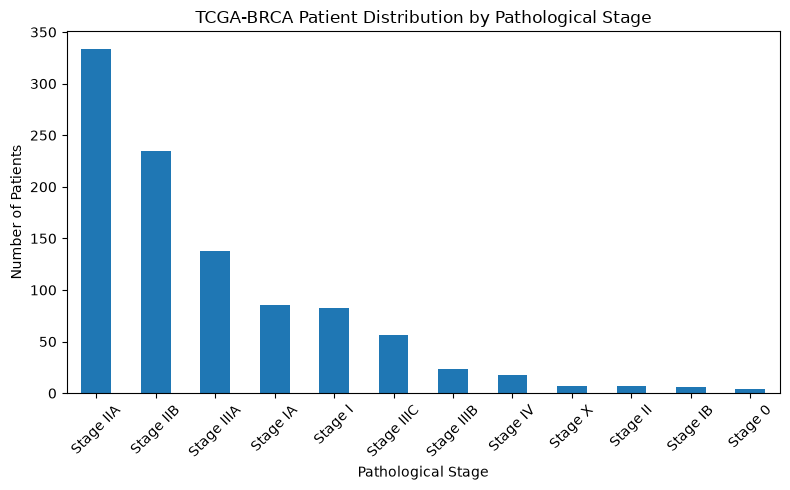

<Figure size 640x480 with 0 Axes>

In [193]:
plt.figure(figsize=(8,5))

stage_counts.plot(
    kind="bar"
)

plt.xlabel("Pathological Stage")
plt.ylabel("Number of Patients")
plt.title("TCGA-BRCA Patient Distribution by Pathological Stage")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()
plt.savefig(
    "../figures/clinical_stage_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

In [194]:
import os

os.listdir("../figures")

['clinical_stage_distribution.png', '.gitkeep', 'age_distribution.png']

In [195]:
clinical_df["age_at_index"].describe()

count    1097.000000
mean       58.450319
std        13.197045
min        26.000000
25%        49.000000
50%        58.000000
75%        67.000000
max        89.000000
Name: age_at_index, dtype: float64

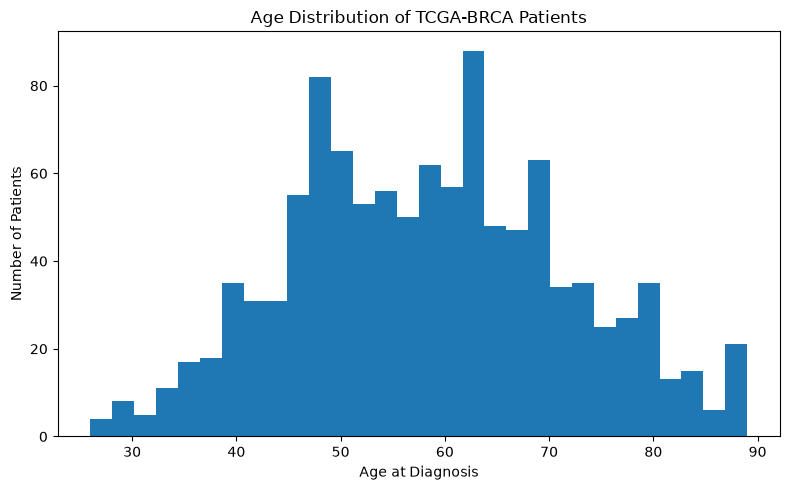

In [196]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

clinical_df["age_at_index"].dropna().plot(
    kind="hist",
    bins=30
)

plt.xlabel("Age at Diagnosis")
plt.ylabel("Number of Patients")
plt.title("Age Distribution of TCGA-BRCA Patients")

plt.tight_layout()

plt.savefig(
    "../figures/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [197]:
import lifelines

print(lifelines.__version__)

0.30.3


In [198]:
!pip install lifelines

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lifelines

print("pandas:", pd.__version__)
print("lifelines:", lifelines.__version__)

pandas: 2.3.3
lifelines: 0.30.3


In [200]:
clinical_df.head()

,patient_id,sex,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,None,None,NaN,NaN,None,NaN,NaN
1,TCGA-A8-A08S,female,Alive,71.0,NaN,None,NaN,NaN
2,TCGA-A8-A09C,female,Alive,69.0,25355.0,Stage X,NaN,NaN
3,TCGA-BH-A1F5,female,Dead,62.0,22842.0,Stage IIA,2712.0,NaN
4,TCGA-A2-A0YT,female,Dead,56.0,20482.0,Stage IIIB,723.0,NaN


In [201]:
import os

os.listdir("../results")

['tcga_brca_clinical_raw.json', 'TCGA_BRCA_clinical_data.csv', '.gitkeep']

In [202]:
import requests
import pandas as pd
import numpy as np

In [203]:
url = "https://api.gdc.cancer.gov/cases"

params = {
    "filters": '{"op":"and","content":[{"op":"in","content":{"field":"project.project_id","value":["TCGA-BRCA"]}}]}',
    "format": "JSON",
    "size": "1100"
}

response = requests.get(url, params=params)

clinical_data = response.json()

clinical_hits_v2 = clinical_data["data"]["hits"]

print(len(clinical_hits_v2))

1098


In [204]:
clinical_rows_final = []

for case in clinical_hits_v2:
    
    demographic = case.get("demographic", {})
    diagnoses = case.get("diagnoses", [])
    
    diagnosis = {}
    if len(diagnoses) > 0:
        diagnosis = diagnoses[0]
    
    clinical_rows_final.append({
        "patient_id": case.get("submitter_id"),
        "sex": demographic.get("sex_at_birth"),
        "vital_status": demographic.get("vital_status"),
        "age_at_index": demographic.get("age_at_index"),
        "age_at_diagnosis_days": diagnosis.get("age_at_diagnosis"),
        "pathologic_stage": diagnosis.get("ajcc_pathologic_stage"),
        "days_to_death": demographic.get("days_to_death"),
        "days_to_last_follow_up": diagnosis.get("days_to_last_follow_up")
    })


clinical_df = pd.DataFrame(clinical_rows_final)

clinical_df.head()

,patient_id,sex,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,None,None,None,None,None,None,None
1,TCGA-A8-A08S,None,None,None,None,None,None,None
2,TCGA-A8-A09C,None,None,None,None,None,None,None
3,TCGA-BH-A1F5,None,None,None,None,None,None,None
4,TCGA-A2-A0YT,None,None,None,None,None,None,None


In [205]:
clinical_df.to_csv(
    "../results/TCGA_BRCA_clinical_data.csv",
    index=False
)

print("saved")

saved


In [206]:
clinical_df = pd.read_csv("../results/TCGA_BRCA_clinical_data.csv")

In [207]:
import os

os.listdir("../results")

['tcga_brca_clinical_raw.json', 'TCGA_BRCA_clinical_data.csv', '.gitkeep']

In [208]:
import json

with open(
    "../results/tcga_brca_clinical_raw.json",
    "w"
) as f:
    json.dump(clinical_hits_v2, f)

print("raw data saved")

raw data saved


In [209]:
clinical_df.head()

,patient_id,sex,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TCGA-A8-A08S,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TCGA-A8-A09C,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TCGA-BH-A1F5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TCGA-A2-A0YT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [210]:
survival_df = clinical_df.copy()

survival_df["event"] = (
    survival_df["vital_status"]
    .map({
        "Dead": 1,
        "Alive": 0
    })
)


survival_df["survival_time"] = np.where(
    survival_df["event"] == 1,
    survival_df["days_to_death"],
    survival_df["days_to_last_follow_up"]
)


survival_df[
    [
        "patient_id",
        "vital_status",
        "survival_time",
        "event"
    ]
].head()

,patient_id,vital_status,survival_time,event
0,TCGA-BH-A0B2,NaN,NaN,NaN
1,TCGA-A8-A08S,NaN,NaN,NaN
2,TCGA-A8-A09C,NaN,NaN,NaN
3,TCGA-BH-A1F5,NaN,NaN,NaN
4,TCGA-A2-A0YT,NaN,NaN,NaN


In [211]:
survival_df["event"].value_counts()

Series([], Name: count, dtype: int64)

In [212]:
clinical_df.columns
clinical_df.head()

,patient_id,sex,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TCGA-A8-A08S,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TCGA-A8-A09C,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TCGA-BH-A1F5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TCGA-A2-A0YT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [213]:
clinical_hits_v2[0].keys()

dict_keys(['id', 'slide_ids', 'submitter_slide_ids', 'disease_type', 'analyte_ids', 'submitter_id', 'submitter_analyte_ids', 'aliquot_ids', 'submitter_aliquot_ids', 'created_datetime', 'sample_ids', 'submitter_sample_ids', 'primary_site', 'updated_datetime', 'case_id', 'state', 'portion_ids', 'submitter_portion_ids'])

In [214]:
import os

os.listdir("../results")

['tcga_brca_clinical_raw.json', 'TCGA_BRCA_clinical_data.csv', '.gitkeep']

In [215]:
clinical_df = pd.read_csv(
    "../results/TCGA_BRCA_clinical_data.csv"
)

clinical_df.head()

,patient_id,sex,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TCGA-A8-A08S,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TCGA-A8-A09C,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TCGA-BH-A1F5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TCGA-A2-A0YT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [217]:
import json

with open("../results/tcga_brca_clinical_raw.json", "r") as f:
    raw_data = json.load(f)

print(type(raw_data))
print(len(raw_data))

<class 'list'>
1098


In [218]:
raw_data[0]

{'id': '57a1604c-60b7-4b30-a75e-f70939532c5c',
 'slide_ids': ['643fd386-3bcb-4ee1-a030-1e34eeefeb04',
  'b3643e0d-dc70-4fd2-a0e0-534890f73da1'],
 'submitter_slide_ids': ['TCGA-BH-A0B2-01A-01-TSA', 'TCGA-BH-A0B2-01A-01-BSA'],
 'disease_type': 'Ductal and Lobular Neoplasms',
 'analyte_ids': ['97f3d921-4fe1-40ad-9f84-e0537372ad3f',
  'c7efa2f3-6724-4cc6-a375-4c6026c019e9',
  'e4b5ef86-2bda-4498-a4f0-42d1a0a65a05',
  '41054d29-473d-4db6-9523-feb4000486a2',
  'fe787c20-f983-4e10-a08b-72a48d07e303'],
 'submitter_id': 'TCGA-BH-A0B2',
 'submitter_analyte_ids': ['TCGA-BH-A0B2-01A-11R',
  'TCGA-BH-A0B2-01A-11D',
  'TCGA-BH-A0B2-10A-01D',
  'TCGA-BH-A0B2-01A-11W',
  'TCGA-BH-A0B2-10A-01W'],
 'aliquot_ids': ['30143b3f-7a18-446f-b3b9-18a6748d7155',
  '760f4cd1-ad18-4acd-a1c9-a9c3f396658d',
  '0a8c0095-44df-4b5e-9479-4a9920692a06',
  'a27c5907-1ad2-4414-a9c9-448f1b484946',
  'de5fed7f-9770-4cb3-85bd-1b0bec7440da',
  '3a713c13-5bc4-4d9c-9e6f-85b2aaa8d85e',
  'ae2856f4-dafc-45b6-96af-6c6615cf9475',
  

In [219]:
raw_data[0].keys()

dict_keys(['id', 'slide_ids', 'submitter_slide_ids', 'disease_type', 'analyte_ids', 'submitter_id', 'submitter_analyte_ids', 'aliquot_ids', 'submitter_aliquot_ids', 'created_datetime', 'sample_ids', 'submitter_sample_ids', 'primary_site', 'updated_datetime', 'case_id', 'state', 'portion_ids', 'submitter_portion_ids'])

In [220]:
import requests
import json

filters = {
    "op": "in",
    "content": {
        "field": "project.project_id",
        "value": ["TCGA-BRCA"]
    }
}

params = {
    "filters": json.dumps(filters),
    "format": "JSON",
    "expand": "demographic,diagnoses",
    "size": 5
}

response = requests.get(
    "https://api.gdc.cancer.gov/cases",
    params=params
)

print(response.status_code)

200


In [221]:
test_data = response.json()
test_hits = test_data["data"]["hits"]

test_hits[0].keys()

dict_keys(['id', 'slide_ids', 'submitter_slide_ids', 'disease_type', 'analyte_ids', 'submitter_id', 'submitter_analyte_ids', 'aliquot_ids', 'submitter_aliquot_ids', 'created_datetime', 'sample_ids', 'submitter_sample_ids', 'primary_site', 'updated_datetime', 'case_id', 'state', 'portion_ids', 'submitter_portion_ids'])

In [222]:
print(response.url)

https://api.gdc.cancer.gov/cases?filters=%7B%22op%22%3A+%22in%22%2C+%22content%22%3A+%7B%22field%22%3A+%22project.project_id%22%2C+%22value%22%3A+%5B%22TCGA-BRCA%22%5D%7D%7D&format=JSON&expand=demographic%2Cdiagnoses&size=5


In [223]:
response.json().get("warnings")


{}

In [224]:
mapping_response = requests.get(
    "https://api.gdc.cancer.gov/cases/_mapping"
)

mapping = mapping_response.json()

mapping["expand"]

['annotations',
 'demographic',
 'diagnoses',
 'diagnoses.annotations',
 'diagnoses.pathology_details',
 'diagnoses.treatments',
 'exposures',
 'family_histories',
 'files',
 'files.analysis',
 'files.analysis.input_files',
 'files.analysis.metadata',
 'files.analysis.metadata.read_groups',
 'files.analysis.metadata.read_groups.read_group_qcs',
 'files.archive',
 'files.center',
 'files.downstream_analyses',
 'files.downstream_analyses.output_files',
 'files.index_files',
 'files.metadata_files',
 'follow_ups',
 'follow_ups.molecular_tests',
 'follow_ups.other_clinical_attributes',
 'project',
 'project.program',
 'samples',
 'samples.annotations',
 'samples.portions',
 'samples.portions.analytes',
 'samples.portions.analytes.aliquots',
 'samples.portions.analytes.aliquots.annotations',
 'samples.portions.analytes.aliquots.center',
 'samples.portions.analytes.annotations',
 'samples.portions.annotations',
 'samples.portions.center',
 'samples.portions.slides',
 'samples.portions.slides

In [225]:
import requests
import json

test_filters = {
    "op": "in",
    "content": {
        "field": "project.project_id",
        "value": ["TCGA-BRCA"]
    }
}

test_params = {
    "filters": json.dumps(test_filters),
    "format": "JSON",
    "expand": "demographic,diagnoses",
    "size": "5"
}

test_response = requests.get(
    "https://api.gdc.cancer.gov/cases",
    params=test_params
)

print("Status:", test_response.status_code)
print("URL:", test_response.url)

Status: 200
URL: https://api.gdc.cancer.gov/cases?filters=%7B%22op%22%3A+%22in%22%2C+%22content%22%3A+%7B%22field%22%3A+%22project.project_id%22%2C+%22value%22%3A+%5B%22TCGA-BRCA%22%5D%7D%7D&format=JSON&expand=demographic%2Cdiagnoses&size=5


In [226]:
test_json = test_response.json()
test_hits = test_json["data"]["hits"]

print(test_hits[0].keys())

dict_keys(['id', 'slide_ids', 'submitter_slide_ids', 'disease_type', 'analyte_ids', 'submitter_id', 'submitter_analyte_ids', 'aliquot_ids', 'submitter_aliquot_ids', 'created_datetime', 'sample_ids', 'submitter_sample_ids', 'primary_site', 'updated_datetime', 'case_id', 'state', 'portion_ids', 'submitter_portion_ids'])


In [227]:
print(test_json.get("warnings"))

{}


In [228]:
print(test_response.url)


https://api.gdc.cancer.gov/cases?filters=%7B%22op%22%3A+%22in%22%2C+%22content%22%3A+%7B%22field%22%3A+%22project.project_id%22%2C+%22value%22%3A+%5B%22TCGA-BRCA%22%5D%7D%7D&format=JSON&expand=demographic%2Cdiagnoses&size=5


In [229]:
import requests

url = "https://api.gdc.cancer.gov/cases"

payload = {
    "filters": {
        "op": "in",
        "content": {
            "field": "project.project_id",
            "value": ["TCGA-BRCA"]
        }
    },
    "format": "JSON",
    "expand": "demographic,diagnoses",
    "size": 5
}

post_response = requests.post(
    url,
    json=payload
)

print("Status:", post_response.status_code)

Status: 200


In [230]:
post_json = post_response.json()

print(post_json.get("warnings"))

post_hits = post_json["data"]["hits"]

post_hits[0].keys()

{}


dict_keys(['id', 'slide_ids', 'submitter_slide_ids', 'disease_type', 'analyte_ids', 'submitter_id', 'submitter_analyte_ids', 'aliquot_ids', 'submitter_aliquot_ids', 'created_datetime', 'sample_ids', 'submitter_sample_ids', 'primary_site', 'updated_datetime', 'case_id', 'state', 'portion_ids', 'submitter_portion_ids'])

In [231]:
import requests
import json

url = "https://api.gdc.cancer.gov/cases"

filters = {
    "op": "in",
    "content": {
        "field": "project.project_id",
        "value": ["TCGA-BRCA"]
    }
}

fields = [
    "submitter_id",
    "demographic.sex_at_birth",
    "demographic.gender",
    "demographic.vital_status",
    "demographic.age_at_index",
    "demographic.days_to_death",
    "diagnoses.ajcc_pathologic_stage",
    "diagnoses.days_to_last_follow_up"
]

params = {
    "filters": json.dumps(filters),
    "fields": ",".join(fields),
    "format": "JSON",
    "size": "5"
}

clinical_test_response = requests.get(
    url,
    params=params
)

print("Status:", clinical_test_response.status_code)

Status: 200


In [232]:
clinical_test_json = clinical_test_response.json()

print(clinical_test_json.get("warnings"))

clinical_test_hits = clinical_test_json["data"]["hits"]

clinical_test_hits[0]

{'fields': 'unrecognized values: [demographic.gender]'}


{'id': '57a1604c-60b7-4b30-a75e-f70939532c5c', 'submitter_id': 'TCGA-BH-A0B2'}

In [233]:
clinical_test_hits[0]

{'id': '57a1604c-60b7-4b30-a75e-f70939532c5c', 'submitter_id': 'TCGA-BH-A0B2'}

In [234]:
case_id = clinical_test_hits[0]["id"]

single_case_url = (
    f"https://api.gdc.cancer.gov/cases/{case_id}"
    "?expand=demographic,diagnoses"
    "&pretty=true"
)

single_response = requests.get(single_case_url)

print(single_response.status_code)

200


In [235]:
single_case = single_response.json()

single_case.keys()

dict_keys(['data', 'warnings'])

In [ ]:
type(raw_data)

list

In [ ]:
len(raw_data)

1098

In [ ]:
raw_data[0].keys()

dict_keys(['id', 'lost_to_followup', 'slide_ids', 'submitter_slide_ids', 'disease_type', 'analyte_ids', 'submitter_id', 'submitter_analyte_ids', 'days_to_consent', 'aliquot_ids', 'submitter_aliquot_ids', 'created_datetime', 'diagnosis_ids', 'sample_ids', 'consent_type', 'submitter_sample_ids', 'primary_site', 'submitter_diagnosis_ids', 'updated_datetime', 'case_id', 'index_date', 'state', 'portion_ids', 'submitter_portion_ids'])

In [ ]:
clinical_hits_v2 = raw_data

In [ ]:
"demographic" in raw_data[0]
"diagnoses" in raw_data[0]

False

In [ ]:
raw_data[0]

{'id': 'e3935ce4-64d3-4a66-ba11-d308b844b410',
 'lost_to_followup': 'Yes',
 'slide_ids': ['7a33a6dd-ab58-456e-8d4d-1033302f4ce8',
  '4543a1a7-ce9f-4038-88da-f7869af4b8fd'],
 'submitter_slide_ids': ['TCGA-E9-A5FL-01Z-00-DX1', 'TCGA-E9-A5FL-01A-01-TSA'],
 'disease_type': 'Complex Epithelial Neoplasms',
 'analyte_ids': ['7a0bb1ec-a255-413e-bfe5-3c1338866d58',
  '34c65d0b-1208-4491-aec8-622f0f158d46',
  '5fb0b6dc-e3e0-4256-80d5-aea22ebdc00a',
  '3ebae004-0eec-4eac-aa47-d0fb12b39128',
  '3e6c553e-5507-457b-b6b2-1e77fce0cf6b',
  '4f833c3d-eb0e-4942-80bc-b135898e2ffc'],
 'submitter_id': 'TCGA-E9-A5FL',
 'submitter_analyte_ids': ['TCGA-E9-A5FL-01A-11W',
  'TCGA-E9-A5FL-01A-11D',
  'TCGA-E9-A5FL-10A-01W',
  'TCGA-E9-A5FL-10A-01D',
  'TCGA-E9-A5FL-01A-41D',
  'TCGA-E9-A5FL-01A-11R'],
 'days_to_consent': 7,
 'aliquot_ids': ['dae7c9a5-51e7-4431-9ad4-4d753ff8023e',
  'b9a3bf18-ddf3-4419-b9ef-a7a9feedceb6',
  '9d80dff6-6d22-46e6-8d4a-d2ff82d30cbb',
  '7cd67d56-1ec6-4232-a4ca-bde62c9e972c',
  '5b67c9

In [ ]:
len(raw_data)

1098

In [ ]:
import os
os.listdir("../results")

['tcga_brca_clinical_raw.json', 'TCGA_BRCA_clinical_data.csv', '.gitkeep']

In [ ]:
clinical_hits_v2[0].keys()

dict_keys(['id', 'lost_to_followup', 'slide_ids', 'submitter_slide_ids', 'disease_type', 'analyte_ids', 'submitter_id', 'submitter_analyte_ids', 'days_to_consent', 'aliquot_ids', 'submitter_aliquot_ids', 'created_datetime', 'diagnosis_ids', 'sample_ids', 'consent_type', 'submitter_sample_ids', 'primary_site', 'submitter_diagnosis_ids', 'updated_datetime', 'case_id', 'index_date', 'state', 'portion_ids', 'submitter_portion_ids'])

In [ ]:
clinical_hits_v2[0]

{'id': '57a1604c-60b7-4b30-a75e-f70939532c5c',
 'slide_ids': ['643fd386-3bcb-4ee1-a030-1e34eeefeb04',
  'b3643e0d-dc70-4fd2-a0e0-534890f73da1'],
 'submitter_slide_ids': ['TCGA-BH-A0B2-01A-01-TSA', 'TCGA-BH-A0B2-01A-01-BSA'],
 'disease_type': 'Ductal and Lobular Neoplasms',
 'analyte_ids': ['97f3d921-4fe1-40ad-9f84-e0537372ad3f',
  'c7efa2f3-6724-4cc6-a375-4c6026c019e9',
  'e4b5ef86-2bda-4498-a4f0-42d1a0a65a05',
  '41054d29-473d-4db6-9523-feb4000486a2',
  'fe787c20-f983-4e10-a08b-72a48d07e303'],
 'submitter_id': 'TCGA-BH-A0B2',
 'submitter_analyte_ids': ['TCGA-BH-A0B2-01A-11R',
  'TCGA-BH-A0B2-01A-11D',
  'TCGA-BH-A0B2-10A-01D',
  'TCGA-BH-A0B2-01A-11W',
  'TCGA-BH-A0B2-10A-01W'],
 'aliquot_ids': ['30143b3f-7a18-446f-b3b9-18a6748d7155',
  '760f4cd1-ad18-4acd-a1c9-a9c3f396658d',
  '0a8c0095-44df-4b5e-9479-4a9920692a06',
  'a27c5907-1ad2-4414-a9c9-448f1b484946',
  'de5fed7f-9770-4cb3-85bd-1b0bec7440da',
  '3a713c13-5bc4-4d9c-9e6f-85b2aaa8d85e',
  'ae2856f4-dafc-45b6-96af-6c6615cf9475',
  

In [ ]:
clinical_hits_v2[0].keys()

dict_keys(['id', 'slide_ids', 'submitter_slide_ids', 'disease_type', 'analyte_ids', 'submitter_id', 'submitter_analyte_ids', 'aliquot_ids', 'submitter_aliquot_ids', 'created_datetime', 'sample_ids', 'submitter_sample_ids', 'primary_site', 'updated_datetime', 'case_id', 'state', 'portion_ids', 'submitter_portion_ids'])

In [ ]:
clinical_hits_v2[0].get("demographic")

In [ ]:
clinical_hits_v2[0].get("diagnoses")

In [ ]:
"demographic" in clinical_hits_v2[0], "diagnoses" in clinical_hits_v2[0]

(False, False)

In [ ]:
list(clinical_hits_v2[0].keys())

['id',
 'slide_ids',
 'submitter_slide_ids',
 'disease_type',
 'analyte_ids',
 'submitter_id',
 'submitter_analyte_ids',
 'aliquot_ids',
 'submitter_aliquot_ids',
 'created_datetime',
 'sample_ids',
 'submitter_sample_ids',
 'primary_site',
 'updated_datetime',
 'case_id',
 'state',
 'portion_ids',
 'submitter_portion_ids']